# Reparametrizing the response

In [1]:
from gammaraytoys import ToyTracker2D
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from gammaraytoys.detectors import Simulator, SimpleTraditionalReconstructor
from gammaraytoys.detectors import PointSource, PowerLawSpectrum, MonoenergeticSpectrum


# Detector 
det = ToyTracker2D(material = 'Ge',
                   layer_length = 10*u.m, 
                   layer_positions = np.append(300, np.arange(0,10,1))*u.cm, 
                   layer_thickness = 1*u.cm, 
                   energy_resolution = 0.03,
                   energy_threshold = 20*u.keV)

In [2]:
from histpy import Histogram, Axis

Ei_axis = Axis(np.geomspace(.2,50,26)*u.MeV, label = 'Ei',scale = 'log')
EmFracError_axis = Axis(np.append(np.linspace(-.5,-.1,16)[:-1], np.linspace(-.1,.1,16)), 
                         label = 'EmDeltaFrac')

h_data_delta = Histogram([Ei_axis, EmFracError_axis])

h_nsim = Histogram(Ei_axis)

By default this notebook **loads the pre-computed response** that ships with the repository instead of regenerating it live: the full generation below (`ntrig=4000` triggered events at each of 25 photon energies) takes on the order of tens of minutes.

The shipped `response_energy_relative_onaxis_traddet.h5` was created using effectively the same simulation loop shown in the cells below -- same detector, same axes, same trigger counts -- via `docs/tutorials/instrument_response/regenerate_responses.py`. The only difference is that script uses a performance-optimized version of the same physics (parallelized across CPU cores, and written to avoid `Quantity` overhead in its hot loop). That optimization is intentionally skipped here so the code below stays in the plain, readable form that's easier to follow -- it's a tutorial, not the production path.

Set `create_my_own = True` below to run the generation yourself and see every intermediate step and plot.

In [3]:
create_my_own = False

In [4]:
%%time
if create_my_own:
    ntrig = 4000 #per energy bin

    for nEi,Ei in enumerate(h_data_delta.axes['Ei'].centers):

        print(f"{nEi}/{h_data_delta.axes['Ei'].nbins}")

        # Source
        source = PointSource(offaxis_angle = 0*u.deg,
                             spectrum = MonoenergeticSpectrum(energy = Ei))
    
        # Getting Em and the CDS
        reco = SimpleTraditionalReconstructor()
    
        # Sims
        sims = Simulator(detector = det, 
                         sources = source, 
                         reconstructor = reco)
    
        for sim_event, reco_event in sims.run_events(ntrig = ntrig):
    
            h_nsim[nEi] += 1
        
            if reco_event.triggered:
            
                frac_energy_error = ((reco_event.energy - Ei)/Ei).to_value('')
    
                h_data_delta.fill(Ei, frac_energy_error)


CPU times: user 3 μs, sys: 1e+03 ns, total: 4 μs
Wall time: 5.72 μs


In [5]:
if create_my_own:
    h_nsim.plot()

In [6]:
if create_my_own:
    h_ntrig = h_data_delta.project('Ei')
    h_ntrig.plot()

In [7]:
if create_my_own:
    Aeff = (h_ntrig/h_nsim) * det.throwing_plane_size
    Aeff.plot()

In [8]:
if create_my_own:
    h_data_delta.plot()
    #h_data_delta._contents[h_data_delta._contents == 0] = 1

In [9]:
if create_my_own:
    energy_dist = h_data_delta/h_ntrig.contents[:,None]
    energy_dist.plot()

In [10]:
if create_my_own:
    phase_space = energy_dist.axes[0].centers[:,None] * energy_dist.axes[1].widths[None,:]

    energy_pdf = energy_dist/phase_space
    #energy_pdf.plot()
    energy_pdf.plot(norm=mpl.colors.LogNorm(clip = True))

In [11]:
if create_my_own:
    fig,ax = plt.subplots()

    cmap = mpl.colormaps['viridis']

    for n,energy in enumerate(energy_dist.axes['Ei'].centers):

        dist = energy_dist.slice[n].project('EmDeltaFrac')

        dist = energy_pdf.slice[n].project('EmDeltaFrac')
        dist *= energy * dist.axis.widths
    
        dist.plot(ax, color = cmap(np.log10(energy.value)/1.5))

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1.5))
    fig.colorbar(sm, ax = ax)

In [12]:
if create_my_own:
    Aeff.write("Aeff_energy_onaxis_traddet.h5", overwrite = True)
    energy_pdf.write("PDF_delta_energy_onaxis_traddet.h5", overwrite = True)

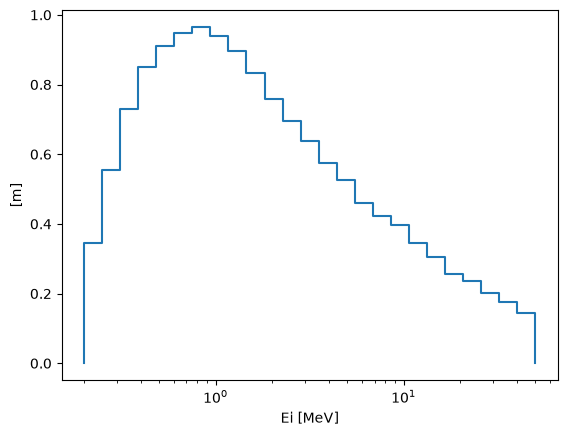

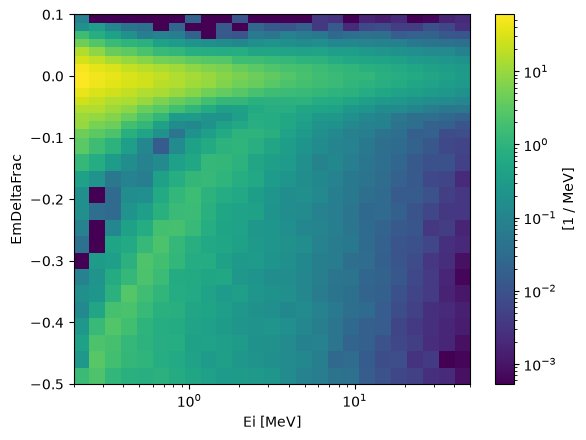

In [13]:
if not create_my_own:
    Aeff = Histogram.open("instrument_response/response_energy_relative_onaxis_traddet.h5", name = 'Aeff')
    energy_pdf = Histogram.open("instrument_response/response_energy_relative_onaxis_traddet.h5", name = 'PDF')

    Aeff.plot()
    energy_pdf.plot(norm=mpl.colors.LogNorm(clip = True))

In [14]:
if create_my_own:
    # Same file
    Aeff.write("instrument_response/response_energy_relative_onaxis_traddet.h5", name = 'Aeff', overwrite = True)
    energy_pdf.write("instrument_response/response_energy_relative_onaxis_traddet.h5", name = 'PDF', overwrite = True)

In [15]:
Ei_axis = Axis(np.geomspace(.2,50,300)*u.MeV, label = 'Ei',scale = 'log')
Em_axis = Axis(np.geomspace(.1,60,301)*u.MeV, label = 'Em',scale = 'log')

Ei_mesh, Em_mesh  = np.broadcast_arrays(Ei_axis.centers[:,None], 
                                        Em_axis.centers[None,:], 
                                        subok = True)

EmDeltaFrac_mesh = ((Em_mesh - Ei_mesh)/Ei_mesh).to_value('')

Rij = Histogram([Ei_axis, Em_axis],
                Em_axis.widths[None,:] * Aeff.interp(Ei_axis.centers)[:,None] * energy_pdf.interp(Ei_mesh, EmDeltaFrac_mesh))

h = Histogram([Ei_axis, Em_axis],
               Em_axis.widths[None,:] * energy_pdf.interp(Ei_mesh, EmDeltaFrac_mesh))


(<Axes: xlabel='Ei [MeV]', ylabel='Em [MeV]'>,
 <matplotlib.collections.QuadMesh at 0x7f93f1523050>)

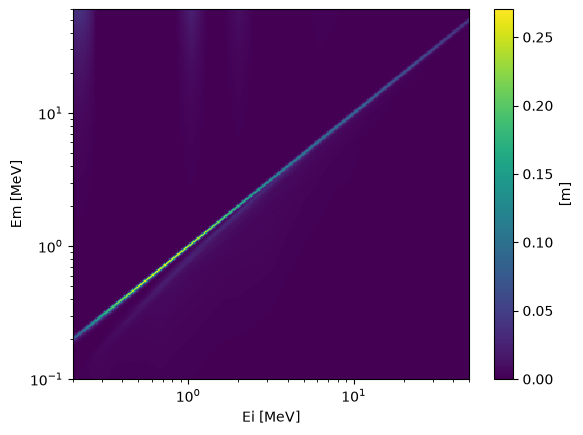

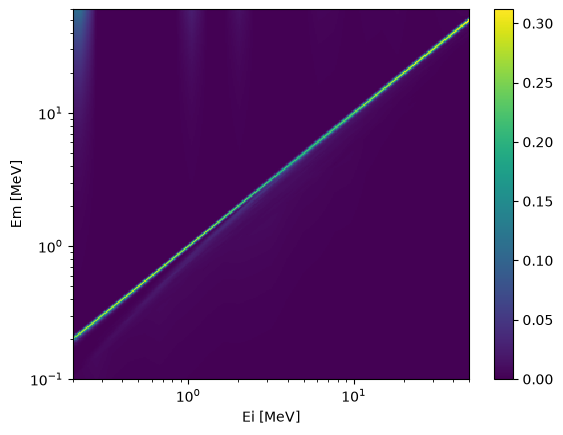

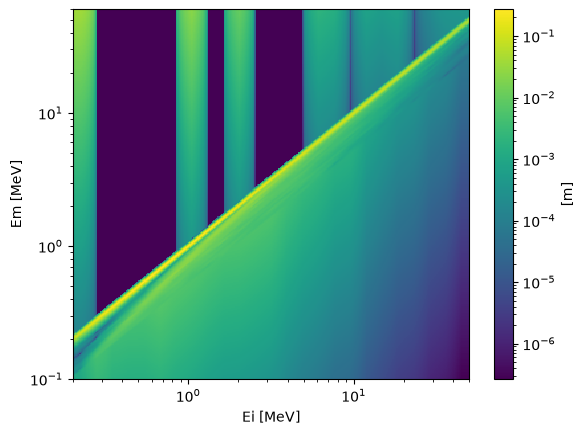

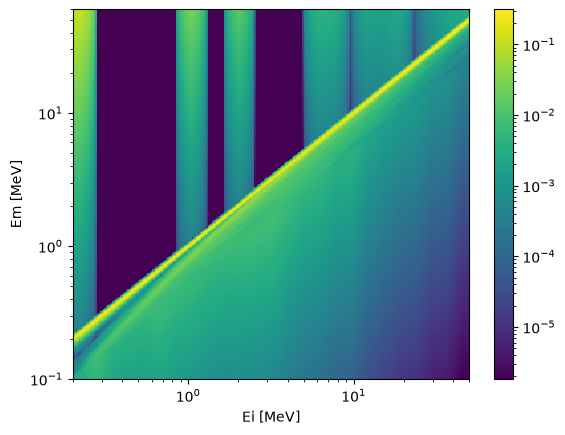

In [16]:
Rij.plot()
h.plot()

Rij.plot(norm=mpl.colors.LogNorm(clip = True))
h.plot(norm=mpl.colors.LogNorm(clip = True))

You can do further optimization. Decouple Aeff (filled quickly) from pdf. Or Change which Ei are sampled. Or maybe re-parametrize the Compton Edge. Seems good enough for the toy model.

## Analysis

In [17]:
flux = 1e-5/u.cm/u.s
line_energy = 2*u.MeV
duration = 10*u.hr

# Source
source = PointSource(offaxis_angle = 0*u.deg,
                     spectrum = MonoenergeticSpectrum(energy = line_energy),
                     flux = flux)

# Getting Em and the CDS
reco = SimpleTraditionalReconstructor()

# Sims
sims = Simulator(detector = det, 
                 sources = source, 
                 reconstructor = reco)

sims.measured_energy_axis = Em_axis

signal = sims.run_binned(duration = duration, axes = 'Em')

  0%|          | 0/376 [00:00<?, ?it/s]

  7%|▋         | 25/376 [00:00<00:01, 232.41it/s]

 13%|█▎        | 50/376 [00:00<00:01, 239.63it/s]

 20%|█▉        | 75/376 [00:00<00:01, 241.98it/s]

 27%|██▋       | 100/376 [00:00<00:01, 219.15it/s]

...

 80%|████████  | 302/376 [00:01<00:00, 225.64it/s]

 86%|████████▋ | 325/376 [00:01<00:00, 223.39it/s]

 93%|█████████▎| 348/376 [00:01<00:00, 203.59it/s]

 98%|█████████▊| 369/376 [00:01<00:00, 201.25it/s]

100%|██████████| 376/376 [00:01<00:00, 202.70it/s]

In [18]:
tot_expectation = (flux * duration * Aeff.interp(line_energy)).to_value('')

# energy_pdf.interp() needs both coordinates to have the same shape (a
# histpy 2.0.7 limitation -- it doesn't broadcast a scalar against an
# array for a multi-dimensional histogram), so broadcast line_energy to
# match the Em_axis-shaped array explicitly.
frac_energy_error = ((Em_axis.centers - line_energy)/line_energy).to_value('')
line_energy_arr = np.full(frac_energy_error.shape, line_energy.value) * line_energy.unit

expectation = tot_expectation * Em_axis.widths * energy_pdf.interp(line_energy_arr, frac_energy_error)

expectation = expectation.to_value('')

np.sum(Em_axis.widths * energy_pdf.interp(line_energy_arr, frac_energy_error))

tot_expectation

np.float64(27.4631627149235)

(1, 3)

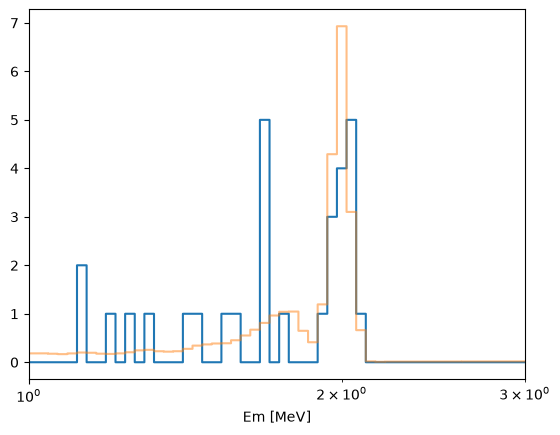

In [19]:
ax,_ = signal.plot()
h_expect = Histogram(Em_axis,expectation)
h_expect.plot(ax, alpha = .5)

ax.set_xlim(1,3)

(<Axes: xlabel='Em [MeV]'>, <ErrorbarContainer object of 3 artists>)

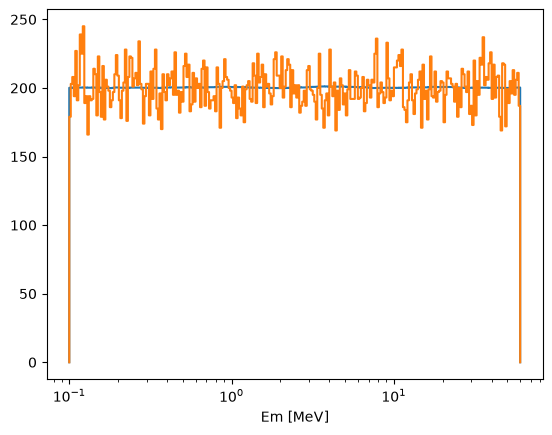

In [20]:
bkg = Histogram(Em_axis)
bkg[:] = np.random.poisson(200, size = bkg.axis.nbins) 

data = bkg + signal

estimated_bkg = Histogram(Em_axis)

masked_bins = 20

for n,energy in enumerate(data.axis.centers):

    left_mask_idx = max(0, n - masked_bins)
    right_mask_idx = min(data.nbins, n + masked_bins)
    
    estimated_bkg[n] = np.mean(np.concatenate([data[:left_mask_idx], data[right_mask_idx:]]))

ax, _ = estimated_bkg.plot()
data.plot(ax)

(<Axes: xlabel='Em [MeV]'>, <ErrorbarContainer object of 3 artists>)

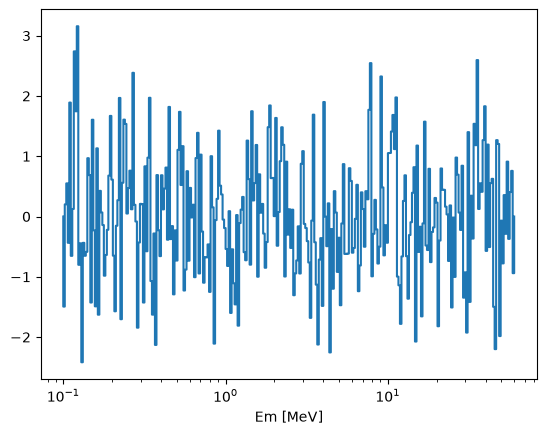

In [21]:
# Do moving window cumsum
rebin = 1
((data.rebin(rebin) - estimated_bkg.rebin(rebin))/np.sqrt(estimated_bkg.rebin(rebin))).plot()

In [22]:
%%time

from gammaraytoys.analysis import poisson_binned_log_likelihood

flux_hyp = 1e-5/u.cm/u.s
Ei_hyp = 2*u.MeV

flux_hyp_axis = Axis(np.geomspace(1e-6, 2e-5, 20)/u.cm/u.s, 
                     label = 'flux',
                     scale = 'log')

Ei_hyp_axis = Axis(np.geomspace(.2, 50, 300)*u.MeV,
                   label = 'energy',
                    scale = 'log')

# Ei_hyp_axis = Axis(np.linspace(1, 3, 20+1)*u.MeV,
#                    label = 'energy',
#                     scale = 'linear')

log_like = Histogram([Ei_hyp_axis, flux_hyp_axis])
log_like0 = Histogram(Ei_hyp_axis)

for nEi, Ei_hyp in enumerate(Ei_hyp_axis.centers):

    print(f"{nEi}/{Ei_hyp_axis.nbins}", end = '\r')
    
    log_like0[nEi] = poisson_binned_log_likelihood(data, estimated_bkg.contents)
    
    for nflux, flux_hyp in enumerate(flux_hyp_axis.centers):

        tot_expectation = (flux_hyp * duration * (Aeff.rebin(4)/4).interp(Ei_hyp))
        
        # See the note above the on-axis expectation cell -- interp() needs
        # matching-shape coordinates, so broadcast Ei_hyp explicitly.
        frac_energy_error = ((Em_axis.centers - Ei_hyp)/Ei_hyp).to_value('')
        Ei_hyp_arr = np.full(frac_energy_error.shape, Ei_hyp.value) * Ei_hyp.unit
        distribution = Em_axis.widths * energy_pdf.interp(Ei_hyp_arr, frac_energy_error)
        
        distribution /= np.sum(distribution) #Workaround finite widths
        expectation = tot_expectation * distribution

        expectation = expectation.to_value('')

        #print(f"{flux_hyp}  {np.sum(expectation)}/{np.sum(signal)}")
    
        
        log_like[nEi, nflux] = poisson_binned_log_likelihood(data, expectation + estimated_bkg.contents)

CPU times: user 6.21 s, sys: 42.6 ms, total: 6.25 s
Wall time: 6.24 s


Penalized from not fitting the right shape! Coherent analysis. ~10-20%

(<Axes: xlabel='energy [MeV]', ylabel='flux [1 / (cm s)]'>,
 <matplotlib.collections.QuadMesh at 0x7f93f16c65d0>)

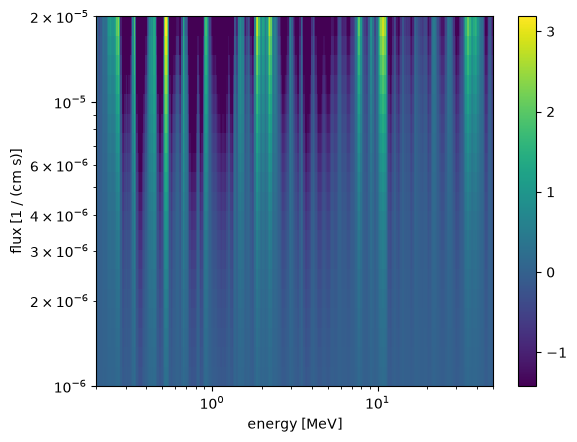

In [23]:
from scipy.stats import chi2

ts = 2*(log_like - log_like0.contents[:,None])

argmax_ts = np.unravel_index(np.argmax(ts), ts.nbins)
max_ts = ts[argmax_ts]

energy_opt = ts.axes[0].centers[argmax_ts[0]] 
flux_opt = ts.axes[1].centers[argmax_ts[1]] 

uncertainty_containment = .9
unc_contour_ts = max_ts - chi2.ppf(uncertainty_containment, df = 2)

fig,ax = plt.subplots()

ts.plot(ax, vmin =  unc_contour_ts)

#ax.set_xlim(1,3)

In [24]:
max_ts


np.float64(3.185076236783061)

(<Axes: xlabel='energy [MeV]'>, <ErrorbarContainer object of 3 artists>)

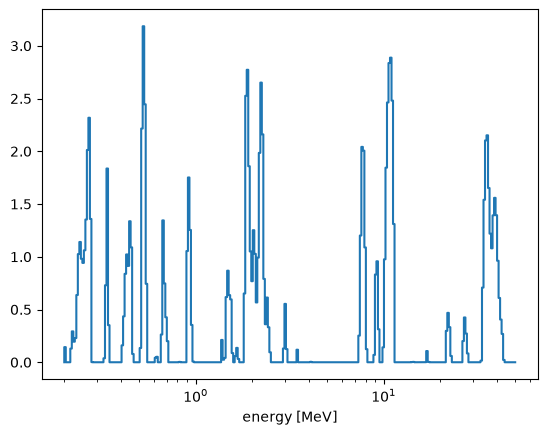

In [25]:
Histogram(ts.axes['energy'], np.maximum(0, np.max(ts, axis = 1))).plot()